In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import xarray as xa

fdir = "/home/jungyoung/Project_win/hh_neuralnet/"

from pytools import hhtools
from pytools import hhclustering as hc
from pytools import utils

from tqdm.notebook import tqdm
from numba import njit

In [36]:
# Load dataset
tag = ""
feature_dims = (15, 15, 3, 16)
# tag = "_mfast"
# tag = "_mslow"
# feature_dims = (15, 15, 3, 5)

with open("../results/twopop_output/summary.pkl", "rb") as fp:
# with open("../results/monopop_output/summary%s.pkl"%(tag), "rb") as fp:
    summary = pkl.load(fp)
    
data = summary["data"].copy()
echelon = np.array([c["rank"] for c in summary["col_names"]])

In [37]:
# load dataset
from sklearn.metrics import silhouette_score

# load result
f = "../results/clustering/kmeans_results%s.pkl"%(tag)
with open(f, "rb") as fp: # or kmeans_pred
    pred_data = pkl.load(fp)
print(len(pred_data["labels"]))

1200


# Kmeans results
Run 'run_kmeans_clustering.py' before running this notebook 

## Identify optimal K

### Intertia

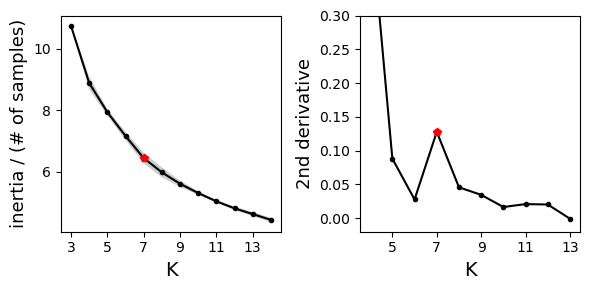

In [41]:
inertia = pred_data["inertia"].reshape([-1, pred_data["nitr"]]) / data.shape[1]
x = pred_data["k"]
m = inertia.mean(axis=1)
s = inertia.std(axis=1)
nopt = 4 

plt.figure(figsize=(6, 3))

plt.subplot(121)
plt.plot(x, m, 'k.-')
plt.fill_between(x, m+s, m-s, color='k', edgecolor="none", alpha=0.2)
plt.xticks(np.arange(x[0], x[-1], 2))
plt.ylabel("inertia / (# of samples)", fontsize=13)
plt.xlabel("K", fontsize=14)
plt.plot(x[nopt], m[nopt], "rp")

plt.subplot(122)
m2 = (m[2:] + m[:-2] - 2*m[1:-1]) / 2
plt.plot(x[1:-1], m2, 'k.-')
plt.xticks(np.arange(x[0], x[-1], 2))
plt.ylabel("2nd derivative", fontsize=13)
plt.xlabel("K", fontsize=14)
plt.ylim([-0.02, 0.3])
plt.plot(x[nopt], m2[nopt-1], "rp")

plt.tight_layout()
plt.show()

### consensus-clustering
Here, we selected local minimum points with K > 3

In [42]:
import warnings
warnings.filterwarnings(action='ignore')

@njit 
def build_consensus_matrix(pred_set, sval_set=None):
    
    npoint = pred_set.shape[1]
    N = pred_set.shape[0]
    sval_set = np.ones(N) if sval_set is None else sval_set
    cmat = np.zeros((npoint, npoint))
    
    for n in range(N):
        s = sval_set[n]
        pred = pred_set[n]
        for i in range(npoint):
            cmat[i, i] += s
            for j in range(i+1, npoint):
                if pred[i] == pred[j]:
                    cmat[i, j] += s
                # cmat[j, i] = cmat[i, j]
    
    cmat = cmat / cmat[0, 0]
    for i in range(npoint):
        for j in range(i):
            cmat[i, j] = cmat[j, i]

    return cmat    

In [44]:
from tqdm import tqdm

de = 0.05
e = np.arange(-de/2, 1+de, de)

hists = []
nmax = pred_data["nitr"]
for n in tqdm(range(len(pred_data["k"]))):
    pred_labels = np.array(pred_data["labels"][n*nmax:(n+1)*nmax])
    
    cmat = build_consensus_matrix(pred_labels, sval_set=pred_data["silhouette"][n*nmax:(n+1)*nmax])
    nbin, _ = np.histogram(cmat, e)
    hists.append(nbin/np.sum(nbin))
    
    del cmat

100%|██████████| 12/12 [01:50<00:00,  9.17s/it]


kopt=7


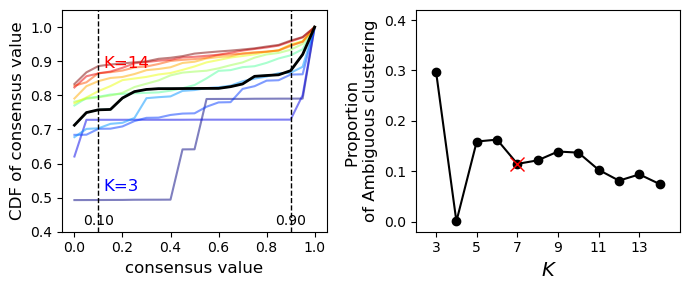

In [46]:
x = (e[1:] + e[:-1])/2
palette = hhtools.get_palette("jet")
ksets = pred_data["k"]

nopt = 4
# nx = [3, 17]
nx = [2, 18]
# nx = [1, 19]

pacs = []
for i in range(len(hists)):
    c = np.cumsum(hists[i])
    pacs.append(c[nx[1]] - c[nx[0]])
    # pacs.append((c[nx[1]] - c[nx[0]])/c[nx[0]])

plt.figure(figsize=(7, 3))
plt.subplot(121)
for i in range(len(hists)):
    plt.plot(x, np.cumsum(hists[i]), c=palette(i/(len(hists)-1)), alpha=0.5)
plt.text(0.12, 0.52, "K=%d"%(ksets[0]), fontsize=12, color="b")
plt.text(0.12, 0.88,  "K=%d"%(ksets[-1]), fontsize=12, color='r')

plt.plot([x[nx]]*2, [0, 1.2], 'k--', lw=1)
plt.plot(x, np.cumsum(hists[nopt]), lw=2, c='k')
plt.xlabel("consensus value", fontsize=12)
plt.ylabel("CDF of consensus value", fontsize=12)
plt.ylim([0.4, 1.05])

for i in range(2):
    plt.text(x[nx[i]], 0.43, "%.2f"%(x[nx[i]]), va="center", ha="center")

plt.subplot(122)
plt.plot(ksets, pacs, 'ko-')
plt.plot(ksets[nopt], pacs[nopt], 'rx', markersize=10)
plt.xlabel("K", fontsize=14, fontstyle="italic")
plt.ylabel("Proportion \nof Ambiguous clustering", fontsize=12)

plt.ylim([-0.02, 0.42])
plt.xlim([2, 15])
plt.xticks(np.arange(3, 15, 2))

print("kopt=%d"%(ksets[nopt]))

plt.tight_layout()
plt.show()

## Clustering results

In [49]:
from importlib import reload

reload(hc)

<module 'pytools.hhclustering' from '/home/jungyoung/Project/info_routing_multifreq/src/pytools/hhclustering.py'>

In [ ]:
from sklearn.metrics import silhouette_samples

cmat_opt = build_consensus_matrix(pred_data["labels"][nopt*nmax:(nopt+1)*nmax])
dmat = 1 - cmat_opt
dmat[dmat <= 0] = 0

model_tree = hc.SLHC(metric="precomputed", method="average") # complete
model_tree.fit(dmat)

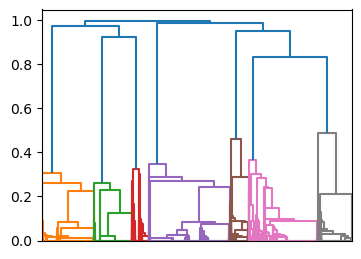

In [52]:
plt.figure(figsize=(4, 3))
model_tree.draw_dend()
plt.show()

In [56]:
cid_tmp = model_tree.cut_dend(dth=0.7)
sq_cid_tmp = np.reshape(cid_tmp, feature_dims)
sq_cid = sq_cid_tmp.copy()

for nr in range(feature_dims[-2]):
    for nw in range(feature_dims[-1]):
        tmp = hc.remove_cluster_island(sq_cid_tmp[:, :, nr, nw], nth=6)
        sq_cid[:, :, nr, nw] = hc.remove_cluster_island(tmp, nth=6)
        
sq_cid, id_old2new = hc.reorder_sq_cluster_id(sq_cid, start_id=1)
cid = sq_cid.flatten()
svals = silhouette_samples(data.T, cid, metric="euclidean")

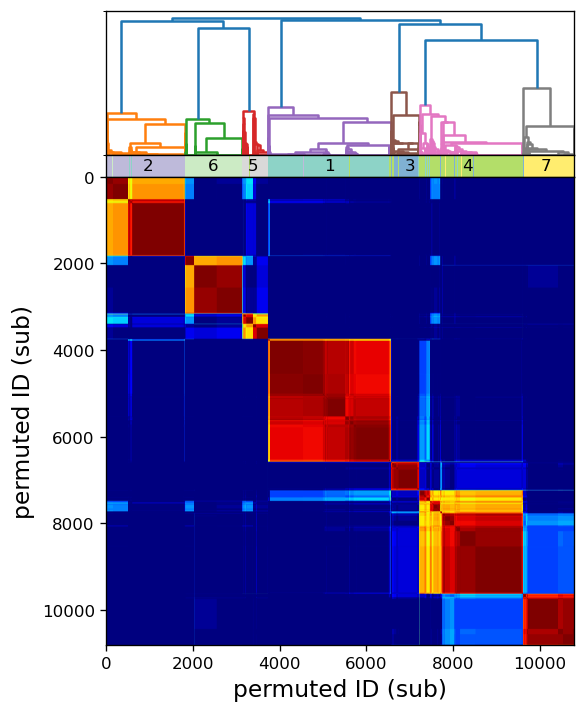

In [57]:
sorted_mat, sort_id = model_tree.sort_dmat(cmat_opt.copy())
fig = hc.draw_with_dendrogram(model_tree.linkmat, sorted_mat, cid[sort_id], label="permuted ID (sub)", color_threshold=0.7)

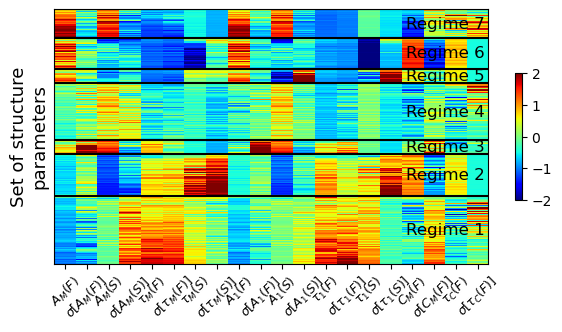

In [68]:
data_order = np.zeros_like(data)
sval = silhouette_samples(data.T, cid)


num_cluster = []
n0 = 0
for nk in range(1, 8):
    is_target = cid==nk
    data_sub = data[:, is_target]
    sval_sub = sval[is_target]
    
    num = np.sum(is_target)
    id_order = np.argsort(sval_sub)[::-1]
    data_order[:, n0:n0+num] = data_sub[:, id_order]
    n0 = n0 + num
    num_cluster.append(num)
    
# smoothing over row
from scipy.signal import savgol_filter

for n in range(data_order.shape[0]):
    x = savgol_filter(data_order[n], 10, 2)
    data_order[n] = x

plt.figure(figsize=(7, 3.3))
plt.imshow(data_order.T, aspect="auto", cmap="jet", vmin=-2, vmax=2, interpolation="None")

xl = plt.xlim()
n0 = 0
for nk in range(1, 8):
    y0 = n0 + num_cluster[nk-1]/2
    plt.text(17.5, y0, "Regime %d"%(nk), ha="center", va="center", fontsize=12)
    
    n0 += num_cluster[nk-1]
    plt.hlines(n0, xl[0], xl[1], color='k')

plt.ylim([0, data.shape[1]])
plt.colorbar(ticks=np.arange(-2, 2.1, 1), shrink=0.5)
plt.xticks(np.arange(data.shape[0]), labels=summary["row_labels"], rotation=45, fontsize=9)

plt.yticks([])
plt.ylabel("Set of structure\nparameters", fontsize=13)

plt.show()

### Save clustering results

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score

sval = silhouette_samples(data.T, cid)
scoef = silhouette_score(data.T, cid)

postdata = xa.load_dataarray("../results/twopop_output/processed_results.nc")

sz = feature_dims
dims = ("alpha", "beta", "rank", "w")
coords = coords=dict(
            alpha=postdata.coords["alpha"].data,
            beta=postdata.coords["beta"].data,
            rank=postdata.coords["rank"].data,
            w=postdata.coords["w"].data
        )

cid_dataset = xa.Dataset(
    data_vars=dict(
        cluster_id=(dims, cid.reshape(*sz)),
        sval=(dims, sval.reshape(*sz))
    ),
    coords=coords,
    attrs=dict(
        id_set=np.unique(cid),
        date=utils.get_date_string(),
        scoef=scoef,
        source="./data/kmeans_sub%s.pkl"%(tag)
    )
)

# cid_dataset.to_netcdf("../results/clustering/cluster_id%s.nc"%(tag))

## Identify landmark

In [70]:
fname_c = "../results/clustering/cluster_id%s.nc"%(tag)
cid_dataset = xa.load_dataset(fname_c)

data = summary["data"].copy()
cid = cid_dataset.cluster_id.data.flatten()
sval = cid_dataset.sval.data.flatten()

In [ ]:
ratio = 0.25
sq_cid = cid.reshape(feature_dims)
sq_sval = sval.reshape(feature_dims)

repr_sval = []
repr_idx = []
repr_params = []

for target_cid in range(1, int(cid.max())+1):
    
    idx_target = np.array(np.where(sq_cid==target_cid))
    sval_target = np.array(sval[cid==target_cid])
    id_sort = np.argsort(sval_target)[::-1]
    idx_target = idx_target[:, id_sort]
    sval_target = sval_target[id_sort]
    sval_target[sval_target <= 0] = 0
    
    nb = int(len(sval_target) * ratio)
    w = sval_target[:nb] / sval_target[:nb].sum()
    idx_sub = idx_target[:,:nb]
    
    x0 = (idx_sub * w).sum(axis=1)
    d = np.sqrt(((idx_target - x0[:, None])**2).sum(axis=0))
    idc = idx_target[:, np.argmin(d)]
    
    s = sq_sval[*idc] / sval_target.max()
    
    repr_sval.append(s)
    repr_idx.append(idc)
    
    
# add 3-control cases
repr_sval.extend([0,0,0])
repr_idx.append([0,0,0,0])
repr_idx.append([0,0,1,0])
repr_idx.append([0,0,2,0])
repr_idx = np.array(repr_idx)

cluster_id = np.concatenate([np.unique(cid), [-1, -2, -3]])

for idc in repr_idx:
    repr_params.append([postdata.coords["alpha"].data[idc[0]],
                        postdata.coords["beta"].data[idc[1]],
                        postdata.coords["rank"].data[idc[2]],
                        postdata.coords["w"].data[idc[3]]])


### Save Landmark info

In [73]:
data = dict(
    repr_idx=repr_idx,
    repr_params=repr_params,
    repr_sval=repr_sval,
    ratio=ratio,
    cluster_id=cluster_id,
    cluster_fname=fname_c
)

fout = "../results/clustering/cluster_landmarks"

# with open("./data/cluster_repr_points%s.pkl"%(tag), "wb") as fp:
#     pkl.dump(data, fp)